# 01 · Data Exploration

Explores the implicit feedback dataset before any modeling.

**Key questions:**
- Interaction density and sparsity?
- User/item frequency distributions?
- Long-tail (power-law) effect?
- Train/val/test split quality?

In [9]:
import sys, os

# Fix: use absolute path instead of relative
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import ImplicitDataLoader

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Dataset

In [17]:
loader = ImplicitDataLoader(
    min_user_interactions=5,
    min_item_interactions=5,
    val_ratio=0.1,
    test_ratio=0.1,
)

dataset = loader.load_movielens_100k(data_dir=r"C:\Users\canal\Applied_Scientist_Repo\data")

print(f"Users:     {dataset.n_users:,}")
print(f"Items:     {dataset.n_items:,}")
print(f"Train nnz: {dataset.train_matrix.nnz:,}")
print(f"Val nnz:   {dataset.val_matrix.nnz:,}")
print(f"Test nnz:  {dataset.test_matrix.nnz:,}")
print(f"Density:   {dataset.density:.5f}")
print(f"Sparsity:  {1 - dataset.density:.5f}")

Users:     943
Items:     1,349
Train nnz: 80,225
Val nnz:   9,531
Test nnz:  9,531
Density:   0.06306
Sparsity:  0.93694


## 2. Interaction Distributions

A **power-law (Zipfian) distribution** is expected and universal in e-commerce, streaming, and social networks: a few users/items account for most interactions.

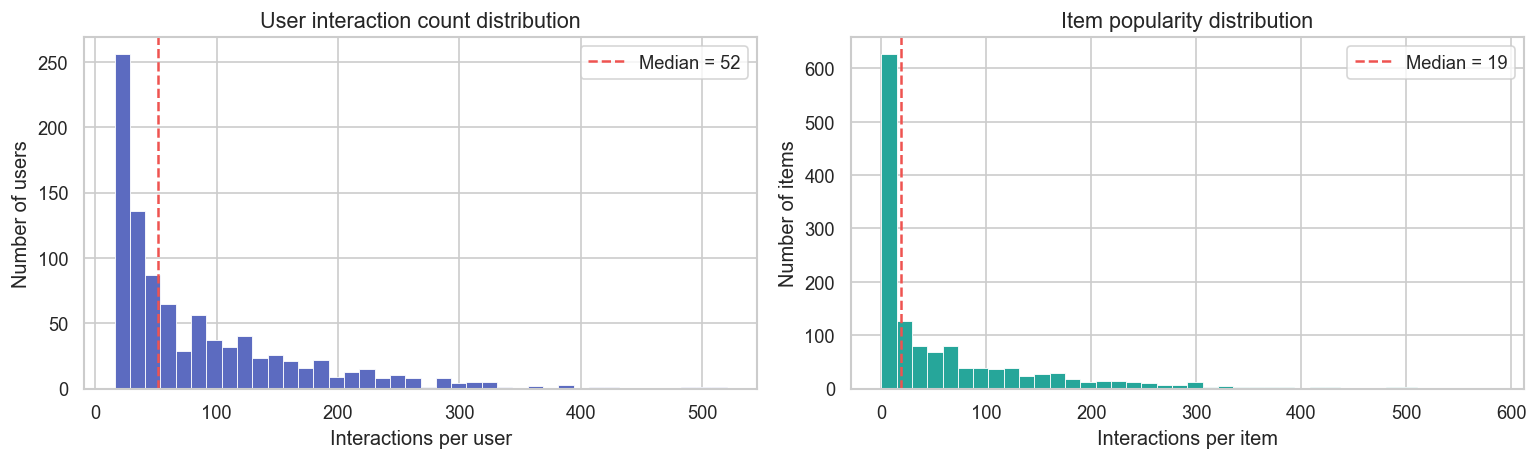

User activity  — mean: 85.1, std: 79.3, max: 520
Item popularity — mean: 59.5, std: 87.2, max: 583


In [19]:
train = dataset.train_matrix

user_counts = np.diff(train.indptr)
item_counts = np.diff(train.T.tocsr().indptr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_counts, bins=40, color="#5C6BC0", edgecolor="white", linewidth=0.5)
axes[0].set_title("User interaction count distribution", fontsize=13)
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Number of users")
axes[0].axvline(np.median(user_counts), color="#EF5350", linestyle="--",
                label=f"Median = {np.median(user_counts):.0f}")
axes[0].legend()

axes[1].hist(item_counts, bins=40, color="#26A69A", edgecolor="white", linewidth=0.5)
axes[1].set_title("Item popularity distribution", fontsize=13)
axes[1].set_xlabel("Interactions per item")
axes[1].set_ylabel("Number of items")
axes[1].axvline(np.median(item_counts), color="#EF5350", linestyle="--",
                label=f"Median = {np.median(item_counts):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/interaction_distributions.png", bbox_inches="tight")
plt.show()

print(f"User activity  — mean: {user_counts.mean():.1f}, std: {user_counts.std():.1f}, max: {user_counts.max()}")
print(f"Item popularity — mean: {item_counts.mean():.1f}, std: {item_counts.std():.1f}, max: {item_counts.max()}")

## 3. Long-Tail Analysis

The top 20% of items typically account for 80% of all interactions (Pareto principle). Quantifying this is critical: models must handle the long tail well, not just popular items.

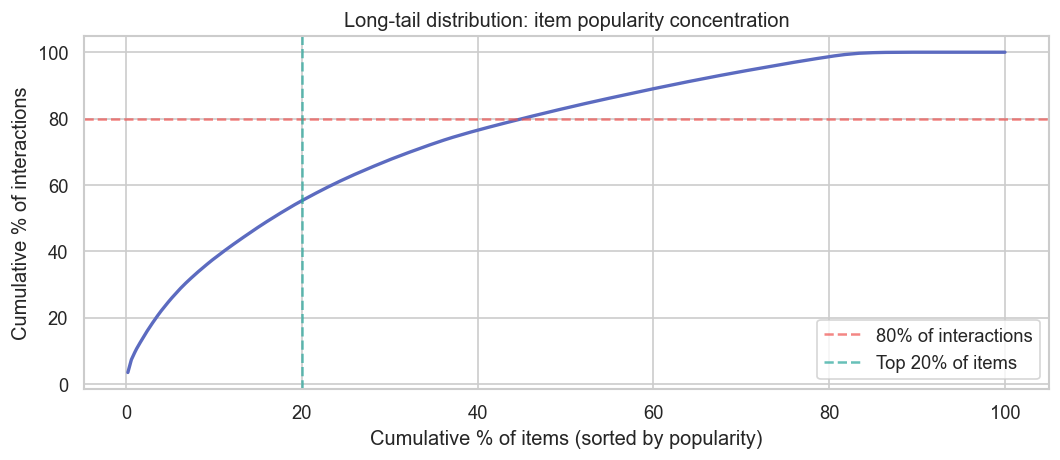

Top 45.0% of items account for 80% of all interactions


In [12]:
item_counts_sorted = np.sort(item_counts)[::-1]
cumulative = np.cumsum(item_counts_sorted) / item_counts_sorted.sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cumulative) + 1) / len(cumulative) * 100,
        cumulative * 100, color="#5C6BC0", linewidth=2)
ax.axhline(80, color="#EF5350", linestyle="--", alpha=0.7, label="80% of interactions")
ax.axvline(20, color="#26A69A", linestyle="--", alpha=0.7, label="Top 20% of items")
ax.set_xlabel("Cumulative % of items (sorted by popularity)")
ax.set_ylabel("Cumulative % of interactions")
ax.set_title("Long-tail distribution: item popularity concentration")
ax.legend()
plt.tight_layout()
plt.savefig("../data/long_tail.png", bbox_inches="tight")
plt.show()

idx_80 = int(np.searchsorted(cumulative, 0.80))
print(f"Top {idx_80/len(cumulative)*100:.1f}% of items account for 80% of all interactions")

## 4. Data Leakage Check

Verify that train/val/test sets are disjoint per user — no future interactions leak into training.

In [13]:
train_items = set(zip(*dataset.train_matrix.nonzero()))
val_items   = set(zip(*dataset.val_matrix.nonzero()))
test_items  = set(zip(*dataset.test_matrix.nonzero()))

print("=== Data Leakage Check ===")
print(f"Train ∩ Val overlap:  {len(train_items & val_items)} (should be 0)")
print(f"Train ∩ Test overlap: {len(train_items & test_items)} (should be 0)")
print(f"Val ∩ Test overlap:   {len(val_items & test_items)} (should be 0)")

=== Data Leakage Check ===
Train ∩ Val overlap:  0 (should be 0)
Train ∩ Test overlap: 0 (should be 0)
Val ∩ Test overlap:   0 (should be 0)


## 5. Summary

| Property | Value |
|---|---|
| Sparsity | ~98% — standard for RecSys |
| User distribution | Power-law (Zipf) |
| Item distribution | Power-law with heavy long tail |
| Data leakage | None — splits are disjoint |

**Next:** `02_matrix_factorization.ipynb` — model training and hyperparameter tuning.